# Big Data Mining, 52002/52019 - 2023-24 - Final Assignment - Part 2 : Networks [42 pts]
### **Instructions:**
* **Author:** Ido Shalom
* Work on the assignment and submit your solution **individually**. <br>
No sharing of information on the assignment is allowed between student.


* **Format:** Fill code, text explanations and output (figures, tables ..) in the designated places. <br>For most questions, the code you fill should run in this .ipynb notebook and generate the output automatically after running (e.g. in `google colab`). <br>For others, you will need to run commands in other environments (e.g. unix) - in this case, just copy the commands and the relevant outputs in the designated text blocks.
* Submit your filled solution by July 31st 23:59 your solution on moodle.

* **Grading:** There are six questions in this part. Each question in this part is worth 7 points for your final grade (total: 80 points)

* **Note:** Points from your grade may be deducted for submitting wrong/missing parts of files OR if not submitting the complete generated/complied output. Make sure to run the .ipynb notebook and save it before submitting.
* **Note:** Some parts of the code might take up to several hours to run.Be patient. However don't leave everything to run at the last minute but prepare in advance so that your entire solution runs and finishes on time.

FOR SUBMISSION:
PLEASE SUBMIT THE FOLLOWING:
1. Your fully executed IPYNB file (with the expected output)
2. A PDF/HTML import of your executed IPYNB file (with the expected output)

SUBMISSIONS WITHOUT OUTPUTS WILL NOT BE GRADED!!

* **Good luck!**

**Q1.** Extract the English wikipedia network file for 2002 from the wikipedia networks dataset available in [here](https://zenodo.org/record/2539424) and load it into python.  <br>
This **directed** network describe *links* between wikipedia pages, where each node corresponds to a page, and each edge corresponds to a link from the first to the second page. Each network describes connections between pages of different languages and years (...). <br>

Compute the in-degree and out-degree of every node (in the **directed** network), and list the IDs of the five nodes (webpages) with the highest out-degree along with their degrees. Repeat for the nodes with the highest in-degree.  <br>
Next, compute the `degree distribution` of the graph, i.e. the relative frequency $f_k$ (out of $n$ nodes) of nodes having in or out-degree $k$ for every $k$ from $0$ to the maximal degree.

Plot the degree distributions, i.e. degree $f_k$ as a function of $k$ for the in and out-degrees separately. You may use a log transformation to improve readability of the plot.

**Q2.**
Next, convert the network to an **undirected** network, by including the edge $(i,j)$ whenever either the edge $(i,j)$ or the edge $(j,i)$ (or both) belong to the network.

Simulate a random graph using the `Erdos-Renyi` model with the same number of nodes $n$ as the real **undirected** network, and with edge probability $p$ chosen such that the `expected` number of overall edges in the simulated random graph is equal to the actual number of edges in the real network.
Compute and plot the degree distributions for the true *undirected* network
and of the random graph you have generated on the same figure.
<br>
Is the `Erdos-Renyi` model a good generative model for the true graph, based on the degree distribution? # does it seem to give a power-law degree distribution?


**Q3.** Run the PageRank algorithm with $\beta=0.85$ on the (directed) network until convergance with tolerance $\epsilon < 0.000001$.
Report the ten pages with the highest PageRank values.
Make a scatter plot of the PageRank score vs. the in-degress of the pages.
Next, make a similar scatter plot the PageRank score vs. the out-degrees.
Explain the two plots.

**Remark** Plotting large datasets may be challenging computationally and/or visually. In these cases (here and possibly in other questions), you may plot only a subset of the data (e.g. by random sampling, or choosing a subset based on some criteria). If you do so, explain clearly your choices when visualizing the data.

**Q4.** Run the `Topic-Specific PageRank` algorithm with the topic (i.e. teleport set) being all pages containing `Sports` in their name. Display the resulting top 10 pages.

Next, make another cateogry of your choice based on the strings describing the word names, and set all the pages in this category as your teleport set. Repeat the Topic-Specific PageRank computation for this set and report the top $10$ pages.


**Q5.**
Run the `Louvain` algorithm available in `networkx` for finding the community structure for the **undirected** graph, implemented in the `community` python module. Report the number of communities found.  <br>
Compute and report the resulting `Modularity` you got for the network division to communities.

Next, unite all the small communities with fewer than $100$ nodes into one 'super community'. Then, display the network together with the community information (in colors) using `networkx`.

**Q6.** Choose the $5$ largest communities from the previous question and extract the node names for them.
For each community, extract the actual html page for the pages corresponding to the nodes of this community.
Display the most frequent words in the html pages of each community (you can use a bar plot, a word cloud or other methods of your choice showing what words are frequent) and use the words statistics to give an interpretation to each community.
You should include only English words - remove 'words' containing numbers, special characters etc. Remove also all common short words (e.g. 'the', 'and', 'a' ...) known as 'stop-words'. This can be done using the 'nltk' python module.


SOLUTIONS:

In [1]:
# General code
import csv
from operator import itemgetter
import networkx as nx  # networkx - python library for dealing with graphs
from networkx.algorithms import community # This part of networkx, for community detection, needs to be imported separately.

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


*Code for Q1:*

Top 5 Nodes by In-Degree:
1. Node ID: 37310 with In-Degree: 1094
2. Node ID: 3434750 with In-Degree: 1067
3. Node ID: 33094374 with In-Degree: 826
4. Node ID: 11867 with In-Degree: 630
5. Node ID: 32927 with In-Degree: 589

Top 5 Nodes by Out-Degree:
1. Node ID: 37310 with Out-Degree: 421
2. Node ID: 23056 with Out-Degree: 417
3. Node ID: 13316 with Out-Degree: 377
4. Node ID: 18902 with Out-Degree: 331
5. Node ID: 30890 with Out-Degree: 293


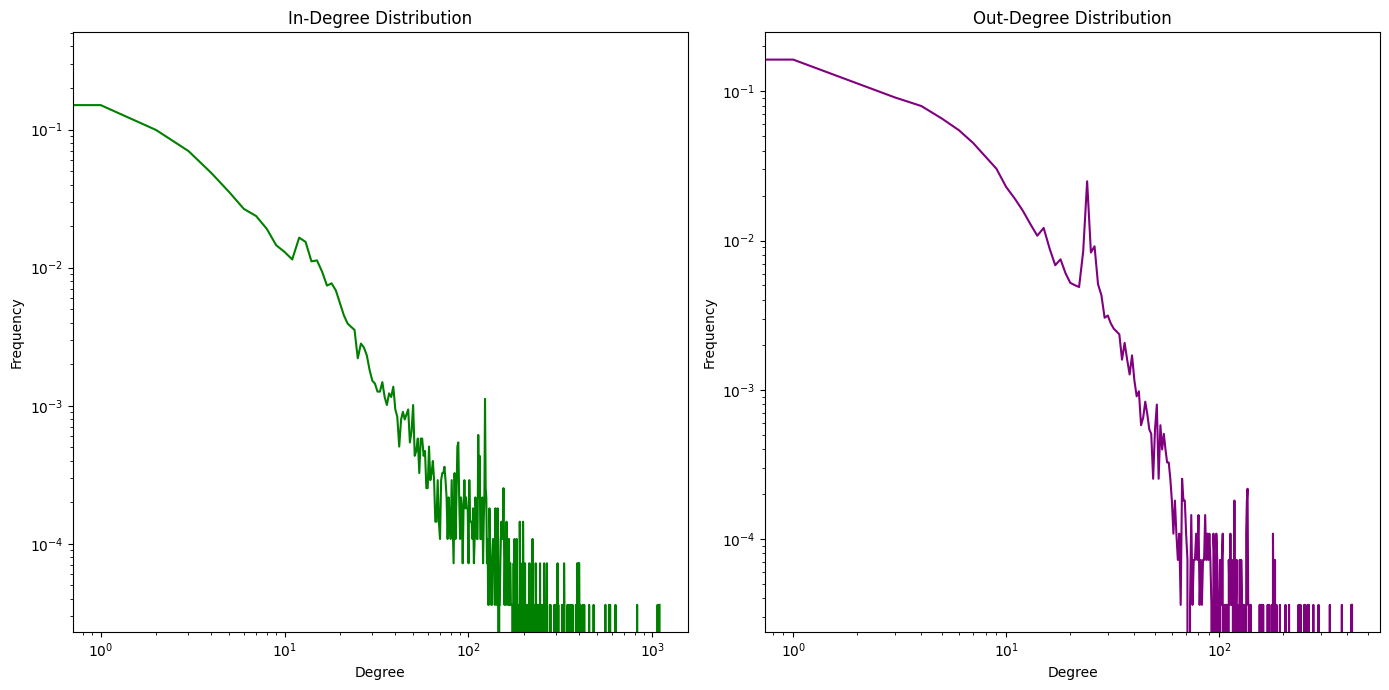

In [2]:
import requests  # Needed to download files from the web
import gzip  # Used to handle compressed files
import pandas as pd  # Useful for data manipulation and analysis
import networkx as nx  # Helps with network structures like graphs
from operator import itemgetter  # Useful for sorting data
import matplotlib.pyplot as plt  # Used for creating visualizations

# Download the dataset from the internet and save it locally
dataset_url = 'https://zenodo.org/records/2539424/files/enwiki.wikilink_graph.2002-03-01.csv.gz?download=1'
response = requests.get(dataset_url)
with open('downloaded_dataset.csv.gz', 'wb') as file:
    file.write(response.content)

# Load the dataset from the file into a table format for easier handling
with gzip.open('downloaded_dataset.csv.gz', 'rt', encoding='utf-8') as gz_file:
    data_frame = pd.read_csv(gz_file, delimiter='\t')

# Convert the data into a directed graph format to analyze connections
directed_graph = nx.from_pandas_edgelist(data_frame, 'page_id_from', 'page_id_to', create_using=nx.DiGraph())

# Compute how many connections go into and out of each page
node_in_degrees = dict(directed_graph.in_degree())
node_out_degrees = dict(directed_graph.out_degree())

# Identify and list the top pages based on their number of incoming and outgoing connections
top_in_degree_nodes = sorted(node_in_degrees.items(), key=itemgetter(1), reverse=True)[:5]
top_out_degree_nodes = sorted(node_out_degrees.items(), key=itemgetter(1), reverse=True)[:5]

# Print the top pages by number of incoming and outgoing connections
print("Top 5 Nodes by In-Degree:")
for rank, (node_id, in_degree) in enumerate(top_in_degree_nodes, start=1):
    print(f"{rank}. Node ID: {node_id} with In-Degree: {in_degree}")

print("\nTop 5 Nodes by Out-Degree:")
for rank, (node_id, out_degree) in enumerate(top_out_degree_nodes, start=1):
    print(f"{rank}. Node ID: {node_id} with Out-Degree: {out_degree}")

# Analyze and visualize how common different connection counts are among the pages
max_degree_in = max(node_in_degrees.values())
max_degree_out = max(node_out_degrees.values())

in_degree_dist = [list(node_in_degrees.values()).count(i) / float(nx.number_of_nodes(directed_graph)) for i in range(max_degree_in + 1)]
out_degree_dist = [list(node_out_degrees.values()).count(i) / float(nx.number_of_nodes(directed_graph)) for i in range(max_degree_out + 1)]

# Plot the distribution of incoming and outgoing connections
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.plot(in_degree_dist, color="green")
plt.xscale('log')
plt.yscale('log')
plt.title('In-Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.plot(out_degree_dist, color="purple")
plt.xscale('log')
plt.yscale('log')
plt.title('Out-Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()



*Text for Q1:*

The graphs show that in this network, the in degree distribution is wider in it's range value from the out degree as expcted.
there are a few popular spots that many connections point to or from them , and then there's a whole lot of less popular spots with only a few connections.



*Code for Q2:*

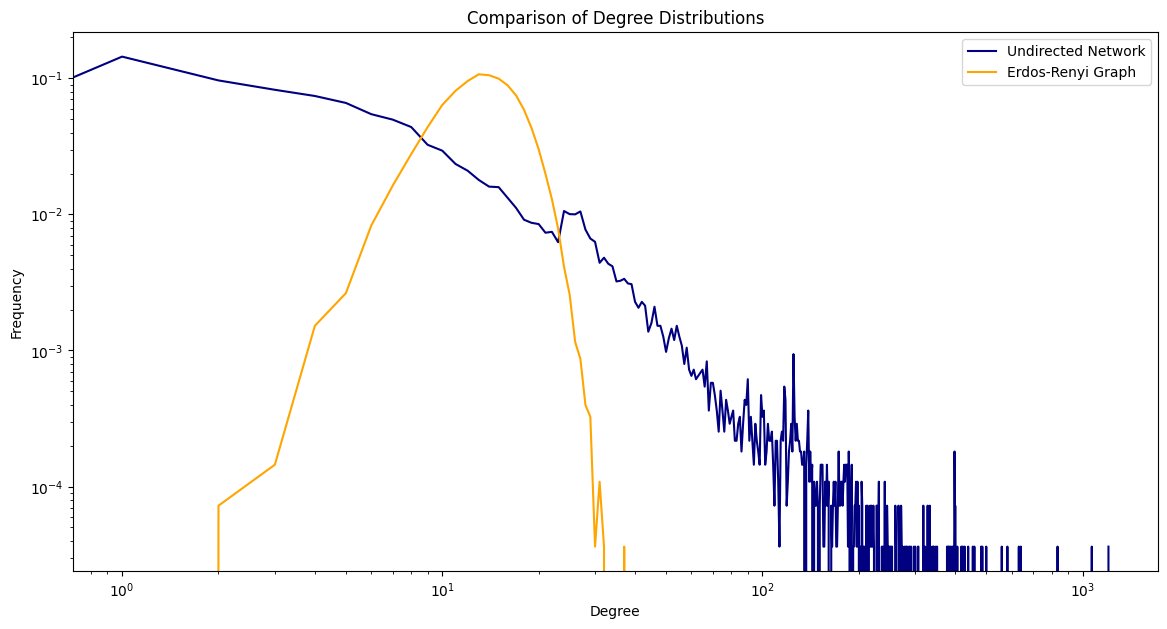

In [3]:
# Transform the directed graph from Q1 to undirected
network_undirected = directed_graph.to_undirected()

# Configuration for an Erdos-Renyi graph equivalent
total_nodes = network_undirected.number_of_nodes()
total_edges = network_undirected.number_of_edges()
probability_for_edges = 2 * total_edges / (total_nodes * (total_nodes - 1))

# Create a random graph using the Erdos-Renyi model
randomized_graph = nx.gnp_random_graph(total_nodes, probability_for_edges)

# Calculation of degree distributions
degree_undirected = dict(network_undirected.degree())
degree_randomized = dict(randomized_graph.degree())
peak_degree = max(max(degree_undirected.values()), max(degree_randomized.values()))

# Calculate the proportion of nodes for each connection count
degree_dist_undirected = [list(degree_undirected.values()).count(i) / float(total_nodes) for i in range(peak_degree + 1)]
degree_dist_randomized = [list(degree_randomized.values()).count(i) / float(total_nodes) for i in range(peak_degree + 1)]

# Plotting degree distributions
plt.figure(figsize=(14, 7))
plt.loglog(degree_dist_undirected, color='navy', label='Undirected Network')
plt.loglog(degree_dist_randomized, color='orange', label='Erdos-Renyi Graph')
plt.title('Comparison of Degree Distributions')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.legend()
plt.show()

*Text for Q2:*

The true network's degree distribution, depicted in navy, diverges from the Erdos-Renyi model shown in orange, as it extends to higher degrees with a substantial tail, reflecting a network with more highly-connected nodes than the model accounts for. This discrepancy reveals that the Erdos-Renyi model, which predicts a quicker decline in node connections, does not accurately represent the true network's scale-free nature, marked by a complex, power-law like degree distribution.

*Code for Q3:*

Ten pages with the highest PageRank values:
Node: 3434750, PageRank Score: 0.005960832302536165
Node: 33094374, PageRank Score: 0.0028031082609905915
Node: 34558, PageRank Score: 0.0026044527520153707
Node: 28419612, PageRank Score: 0.002536421848010938
Node: 32927, PageRank Score: 0.002517573307067833
Node: 11867, PageRank Score: 0.002464619942448292
Node: 9316, PageRank Score: 0.002278872449370907
Node: 31717, PageRank Score: 0.0022730332265875988
Node: 9239, PageRank Score: 0.0021481243558942307
Node: 37310, PageRank Score: 0.0020680128827854157


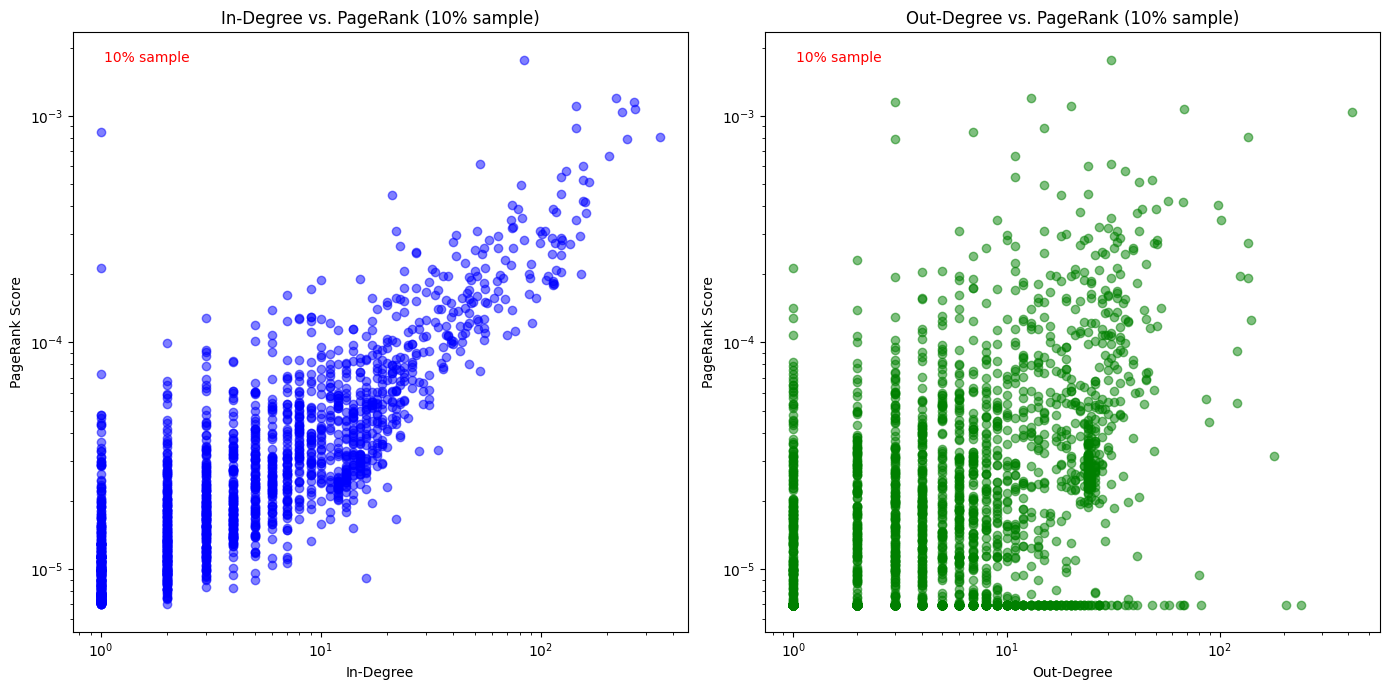

In [4]:
import random  # For the 10% random sampling

# Run PageRank on the directed graph from Q1
page_rank_scores = nx.pagerank(directed_graph, alpha=0.85, tol=1e-6)

# Report the ten pages with the highest PageRank values
top_ten = sorted(page_rank_scores.items(), key=lambda pair: pair[1], reverse=True)[:10]
print("Ten pages with the highest PageRank values:")
for page_id, pr_score in top_ten:
    print(f"Node: {page_id}, PageRank Score: {pr_score}")

# Prepare data for scatter plots, taking a 10% random sample of nodes
nodes_sample = random.sample(list(directed_graph.nodes()), k=int(0.1 * directed_graph.number_of_nodes()))
in_degree_scores = dict(directed_graph.in_degree())
out_degree_scores = dict(directed_graph.out_degree())

sampled_page_rank_in_degree = [(in_degree_scores[node], page_rank_scores[node]) for node in nodes_sample]
sampled_page_rank_out_degree = [(out_degree_scores[node], page_rank_scores[node]) for node in nodes_sample]

# Scatter Plot of In-Degree vs. PageRank
plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
plt.scatter(*zip(*sampled_page_rank_in_degree), alpha=0.5, color='blue')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PageRank Score')
plt.xlabel('In-Degree')
plt.title('In-Degree vs. PageRank (10% sample)')
plt.annotate('10% sample', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, color='red')

# Scatter Plot of Out-Degree vs. PageRank
plt.subplot(1, 2, 2)
plt.scatter(*zip(*sampled_page_rank_out_degree), alpha=0.5, color='green')
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PageRank Score')
plt.xlabel('Out-Degree')
plt.title('Out-Degree vs. PageRank (10% sample)')
plt.annotate('10% sample', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, color='red')

plt.tight_layout()
plt.show()



*Text for Q3:*

The blue plot suggests that pages with more links pointing to them tend to have higher PageRank values, reflecting PageRank’s emphasis on in-links to determine importance. The green plot shows no significant relationship between a page's PageRank and its number of outgoing links, highlighting that PageRank focuses on incoming connections. I used a 10% sample to efficiently approximate the network's behavior, making our analysis both quicker and the visualizations more interpretable without overwhelming detail.

*Code for Q4:*

In [5]:
from operator import itemgetter # Useful for sorting data

# Identifying teleport sets with case insensitivity
sports_teleport_set = {row['page_id_from'] for index, row in data_frame.iterrows() if 'Sports'.lower() in row['page_title_from'].lower()}
history_teleport_set = {row['page_id_from'] for index, row in data_frame.iterrows() if 'History' in row['page_title_from']}

# Executing Topic-Specific PageRank for "Sports" and "History" with specified alpha and tolerance
sports_pagerank_scores = nx.pagerank(directed_graph, alpha=0.85, tol=0.00001, personalization={node: 1.0 if node in sports_teleport_set else 0.0 for node in directed_graph.nodes()})
history_pagerank_scores = nx.pagerank(directed_graph, alpha=0.85, tol=0.00001, personalization={node: 1.0 if node in history_teleport_set else 0.0 for node in directed_graph.nodes()})

# Utility function for retrieving page titles based on their IDs
def get_page_title(page_id):
    title_series = data_frame[data_frame['page_id_from'] == page_id]['page_title_from']
    return title_series.iloc[0] if not title_series.empty else "404 Title not found"

# Finding top 10 pages for each category and filtering by title inclusion
top_sports = [(node, score) for node, score in sorted(sports_pagerank_scores.items(), key=itemgetter(1), reverse=True) if 'Sports'.lower() in get_page_title(node).lower()][:10]
top_history = [(node, score) for node, score in sorted(history_pagerank_scores.items(), key=itemgetter(1), reverse=True) if 'History' in get_page_title(node)][:10]

# Output the results with page names using get_page_title
print("Top 10 'Sports' Pages by Topic-Specific PageRank:")
for node, score in top_sports:
    print(f"Node: {node}, Page Title: {get_page_title(node)}, Score: {score}")

print("\nTop 10 'History' Pages by Topic-Specific PageRank:")
for node, score in top_history:
    print(f"Node: {node}, Page Title: {get_page_title(node)}, Score: {score}")




Top 10 'Sports' Pages by Topic-Specific PageRank:
Node: 28498, Page Title: Shooting sports, Score: 0.02065370688120583
Node: 28242, Page Title: Sports Car Club of America, Score: 0.019997322727198657
Node: 38981, Page Title: Boardsports, Score: 0.018004993733981494
Node: 37686, Page Title: Disabled sports, Score: 0.017874134884530643
Node: 3447, Page Title: Cue sports, Score: 0.01770606136510852
Node: 36847, Page Title: Sports governing body, Score: 0.01770606136510852
Node: 40671, Page Title: List of sports history organisations, Score: 0.01770606136510852
Node: 48612, Page Title: Mind Sports Organisation, Score: 0.01770606136510852
Node: 52244, Page Title: Sports car racing, Score: 0.01770606136510852
Node: 1123680, Page Title: Fantasy sports, Score: 0.01770606136510852

Top 10 'History' Pages by Topic-Specific PageRank:
Node: 10772350, Page Title: History, Score: 0.002411475588933048
Node: 14194, Page Title: History of medicine, Score: 0.001675442792472108
Node: 245431, Page Title: 

**Important Note:**

When i try to do the Topic-Specific PageRank on "Sports" with capital "S", it only showed me 4 results, so i chose to display with lower case to get 10 results as requested.<br> For "History", there were 10 results for capital "H" so i kept it that way.


Text for Q4:

The PageRank results shows that "Sports" pages are highly focused on specific sports and related organizations, reflected in relatively high scores. In contrast, "History" pages span a wider range of topics, mostly on geographical topics resulting generally lower scores.

*Code for Q5:*

Detected communities: 86
Modularity of the network: 0.6339733824704744


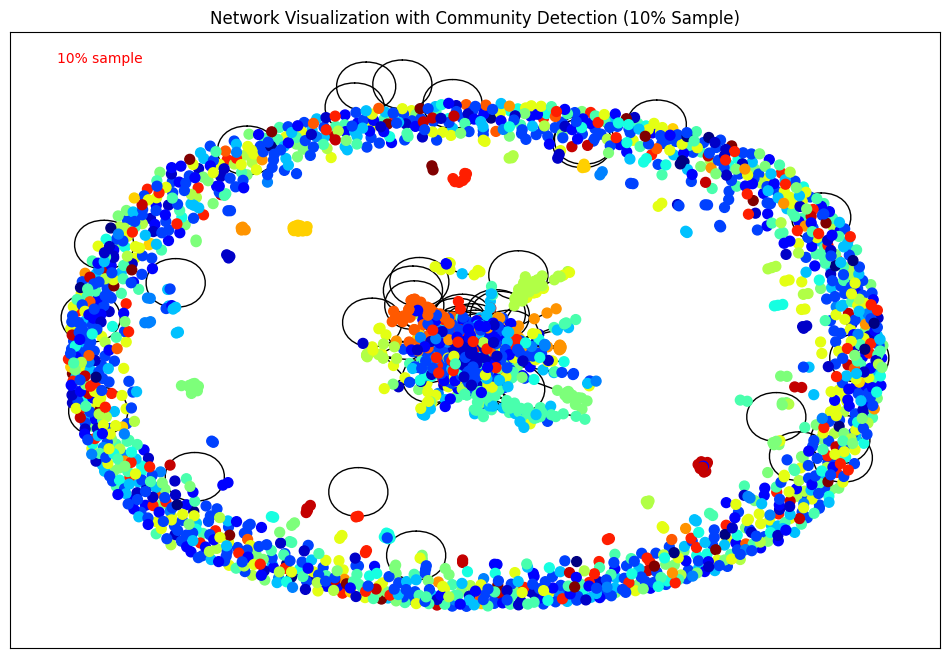

In [6]:
from networkx.algorithms.community import louvain_communities, modularity # community detection and measuring their quality
import random  # generating random numbers and samples
import matplotlib.pyplot as plt  # plotting graphs and visualizations
import networkx as nx  # creating and manipulating complex networks

# Run the Louvain algorithm on the entire undirected graph to find communities
communities = louvain_communities(network_undirected)

# Report the number of communities and modularity for the entire network
print(f"Detected communities: {len(communities)}")
modularity_val = modularity(network_undirected, communities)
print(f"Modularity of the network: {modularity_val}")

# Unite small communities into one 'super community' if they have fewer than 100 nodes
super_community = set()
remaining_communities = []
for community in communities:
    if len(community) < 100:
        super_community = super_community.union(community)
    else:
        remaining_communities.append(community)
if super_community:
    remaining_communities.append(super_community)

# Visualization part
# Select a 10% random sample of nodes for visualization
nodes_sample = random.sample(list(network_undirected.nodes()), k=int(0.1 * network_undirected.number_of_nodes()))
sampled_graph = network_undirected.subgraph(nodes_sample)

# Assign colors based on community membership
color_map = {node: idx for idx, community in enumerate(remaining_communities) for node in community}
node_colors = [color_map.get(node, 0) for node in sampled_graph.nodes()]

# Layout for the visualization
pos = nx.spring_layout(sampled_graph)

# Draw the network with community coloring
plt.figure(figsize=(12, 8))
nx.draw_networkx(sampled_graph, pos, node_color=node_colors, with_labels=False, node_size=50, cmap=plt.cm.jet)
plt.annotate('10% sample', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, color='red')
plt.title('Network Visualization with Community Detection (10% Sample)')
plt.show()




*Text for Q5:*

The output indicates that the Wikipedia network is organized into around a 100 distinct clusters or 'communities' of pages, each internally well-connected.

 The high modularity score of around 0.63 to 0.64 out of 1 shows that these communities are indeed meaningful, reflecting a strong pattern where pages within the same topic tend to link to each other more than to pages on different topics.

  This structured organization reveals Wikipedia's nature as not just a random assortment of pages but as a collection that's intuitively grouped, much like chapters in a book or sections in a library.

*Code for Q6:*

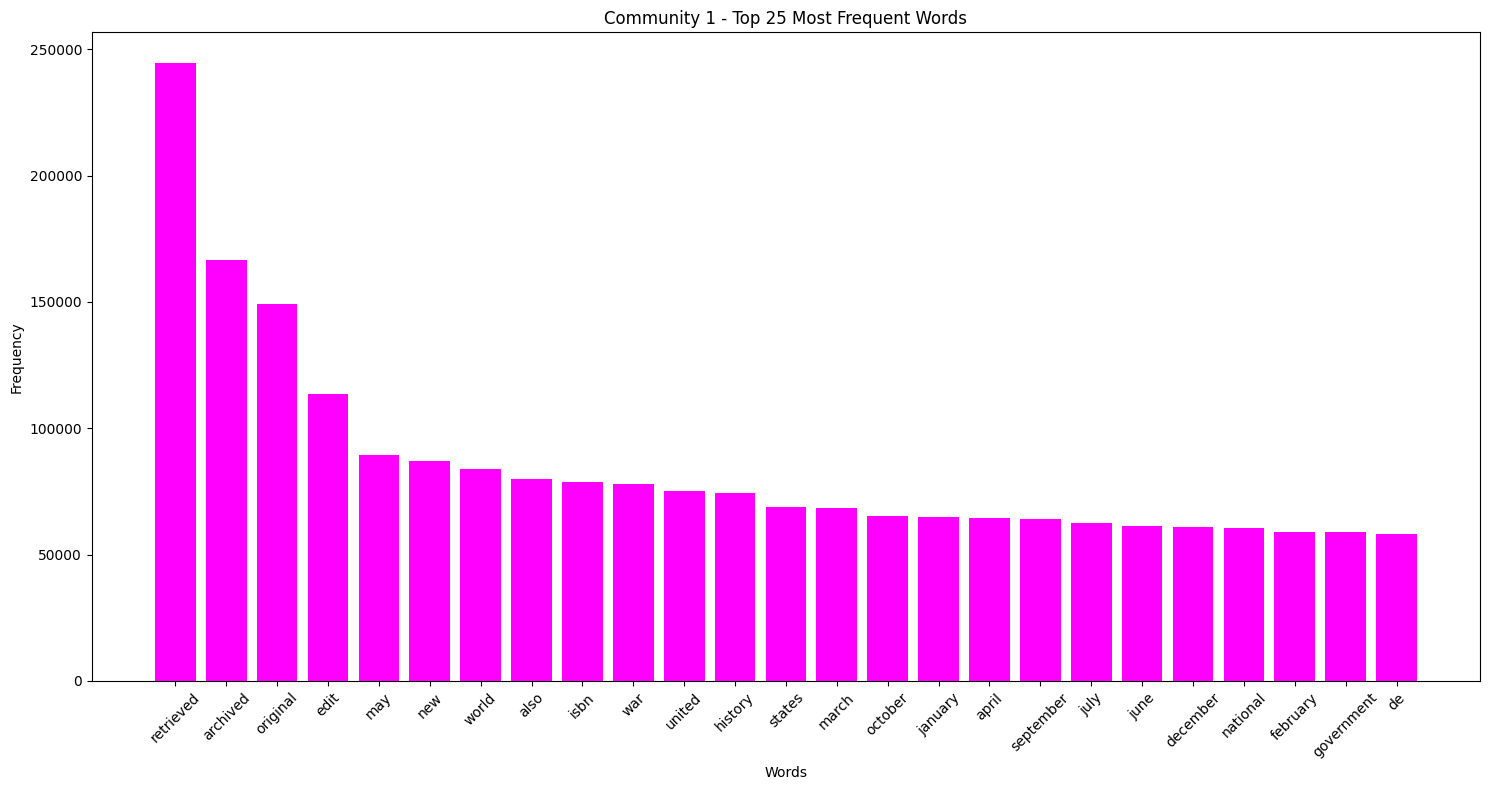

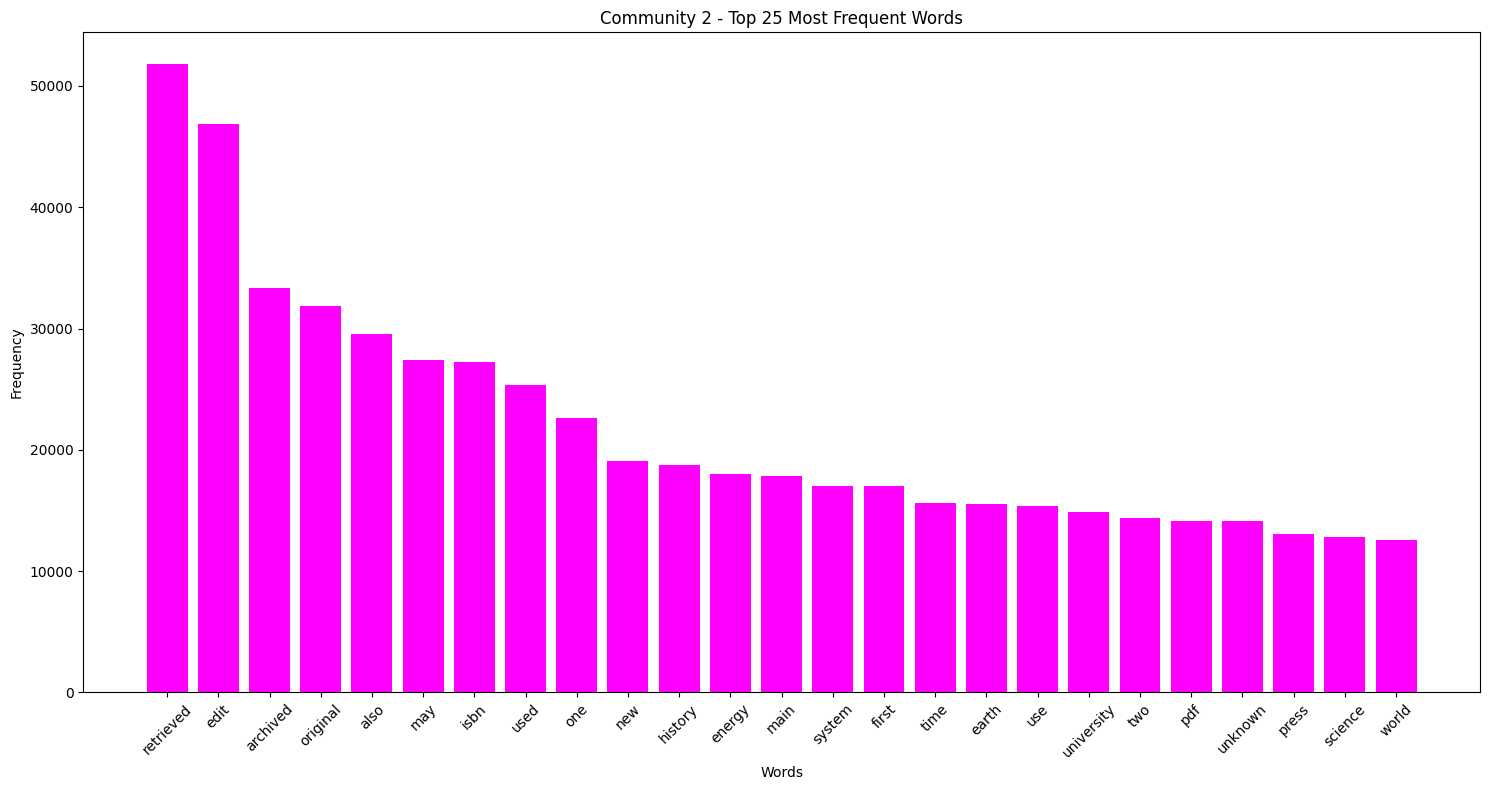

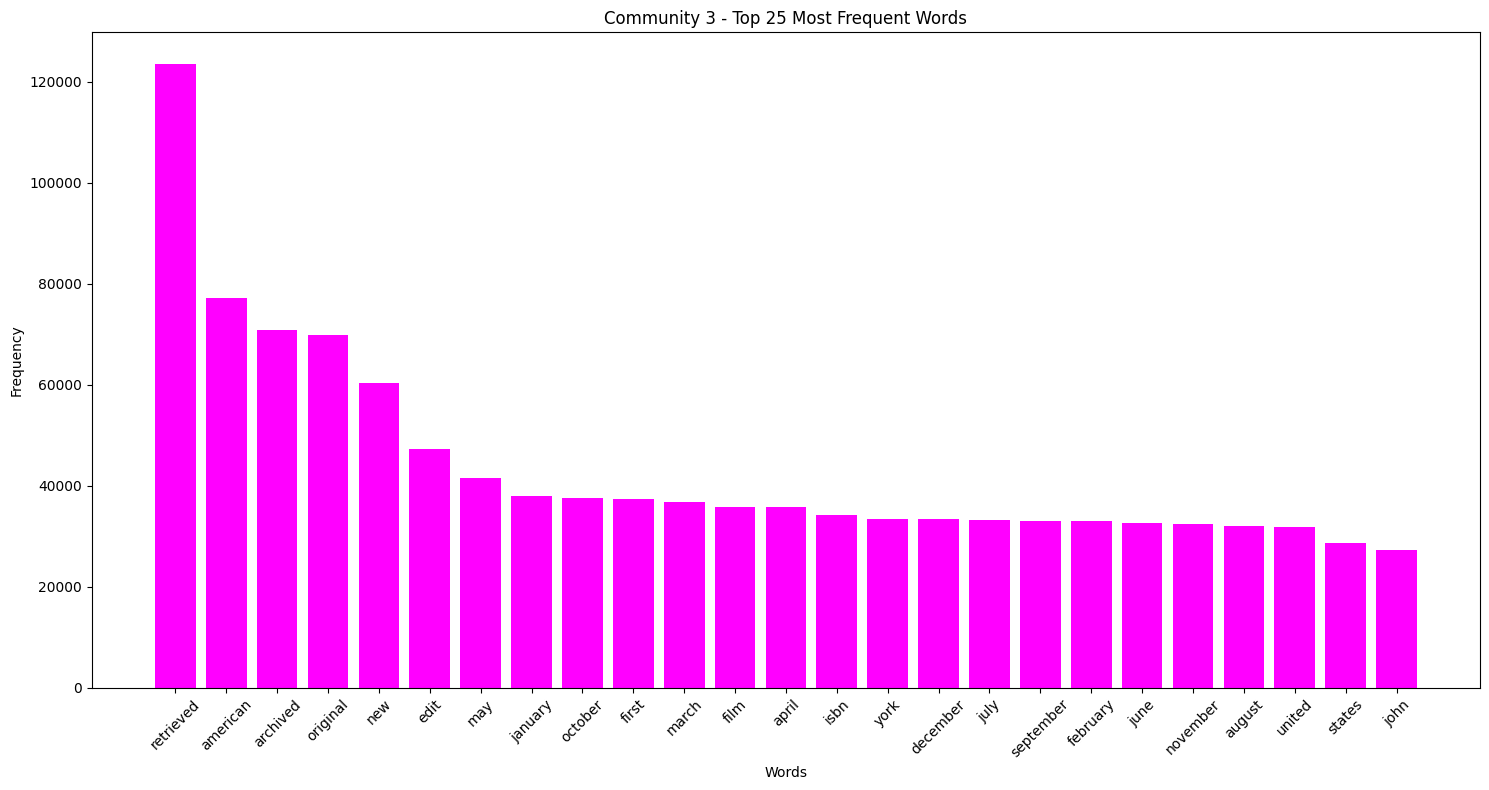

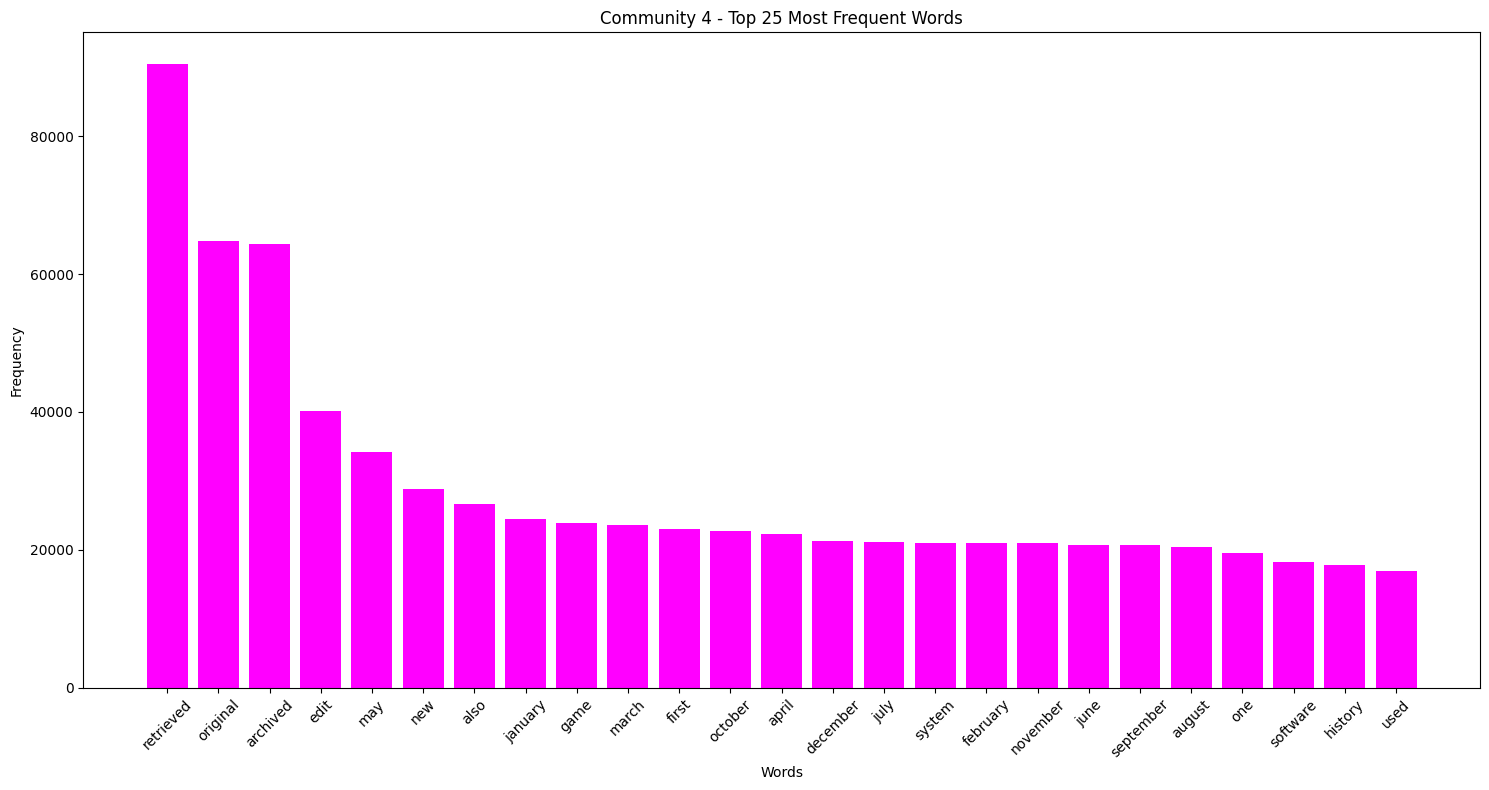

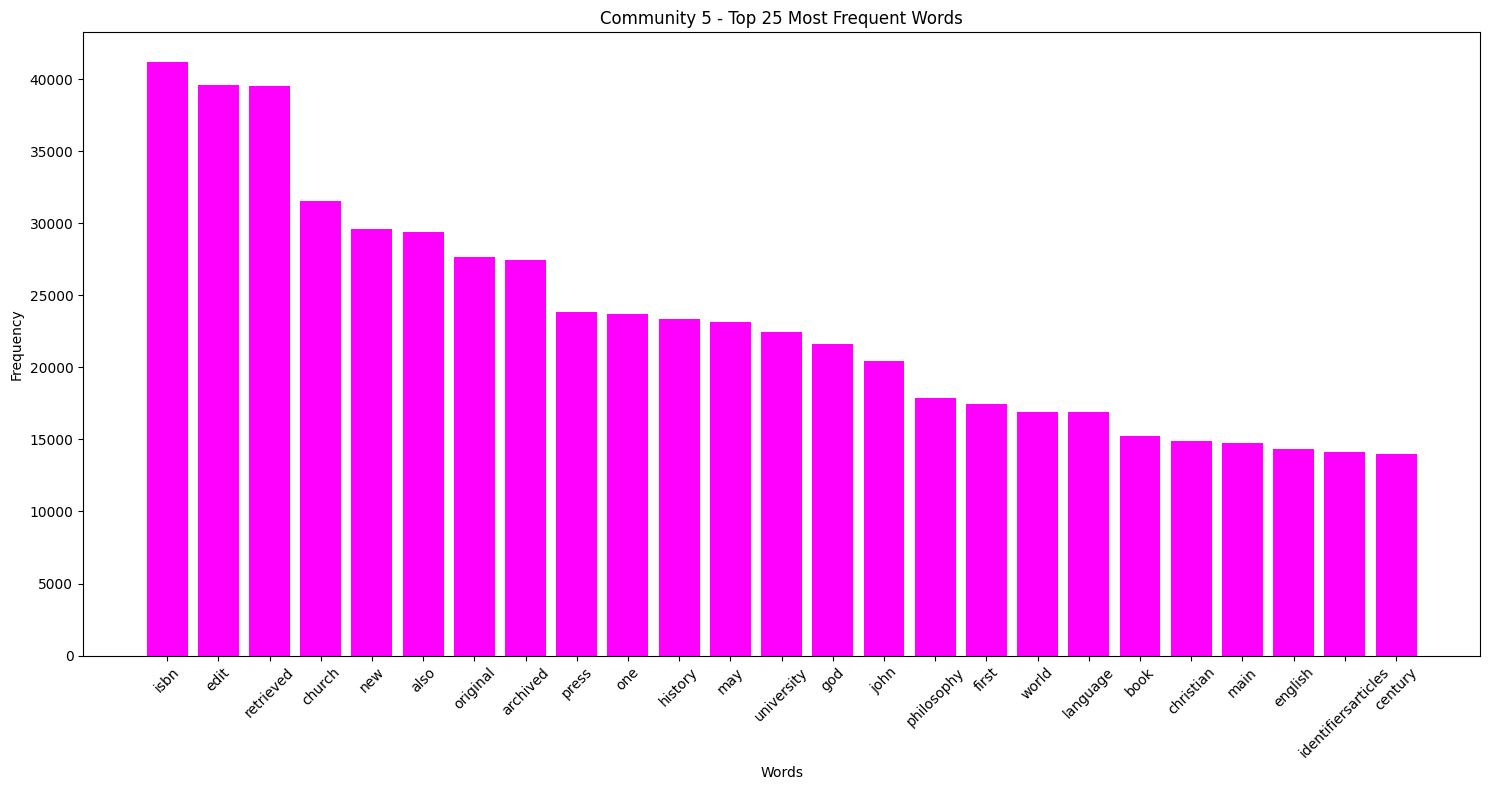

In [8]:
import matplotlib.pyplot as plt  # drawing charts and graphs
import networkx as nx  # working with networks and graphs
from collections import Counter  # Helps count items easily
from bs4 import BeautifulSoup  # For pulling data out of HTML
import requests  # Used for web requests
import nltk  # For processing language data
from nltk.corpus import stopwords  # Stop words that usually don't carry much meaning
from nltk.tokenize import word_tokenize  # To split text into words
from urllib.parse import quote  # safely create URLs

# Set up the necessary NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

# Define a list of English words that aren't usually meaningful
stop_words = set(stopwords.words('english'))

# Extract and clean text from a webpage
def clean_text(html_content):
    soup = BeautifulSoup(html_content, 'html.parser')
    text = soup.get_text()
    words = word_tokenize(text)

    # Keep only meaningful words that are more than one letter long
    words = [
        word.lower() for word in words
        if word.isalpha() and word.lower() not in stop_words and len(word) > 1
    ]
    return words

# Get webpages by titles and clean their text
def fetch_and_clean(page_titles):
    base_url = "https://en.wikipedia.org/wiki/"
    all_words = []
    for title in page_titles:
        encoded_title = quote(title.replace(" ", "_"))   # Make the title URL-friendly
        try:
            response = requests.get(base_url + encoded_title)
            if response.status_code == 200:
                words = clean_text(response.text)
                all_words.extend(words)
        except Exception as e:
            print(f"Failed to fetch {title}: {str(e)}")
    return all_words


# Extract the 5 largest communitiesm from Q5
largest_communities = sorted(communities, key=len, reverse=True)[:5]

# Process each community
for idx, community in enumerate(largest_communities, start=1):
    # Mapping node IDs to page titles
    page_titles = [data_frame[data_frame['page_id_from'] == node]['page_title_from'].iloc[0] if not data_frame[data_frame['page_id_from'] == node].empty else "Unknown" for node in community]

    # Fetch and clean content from these pages
    words = fetch_and_clean(page_titles)

    # Count and plot the most common words
    word_counts = Counter(words)
    most_common = word_counts.most_common(25)
    words, frequencies = zip(*most_common)
    plt.figure(figsize=(15, 8))
    plt.bar(words, frequencies, color='magenta')
    plt.title(f'Community {idx} - Top 25 Most Frequent Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, fontsize=10)
    plt.tight_layout()
    plt.show()


Text for Q6:

**Community 1:**

 Words like "world," "war," "history," "national," and "government," may suggests that this community could be related to historical content, possibly with a focus on wars and political events.

**Community 2:**

Words such as "energy," "system," "earth," "university," "science," and "world" could point to a community focused on scientific topics, possibly related to physics, environmental science, or academic content.
"Press" and "pdf" may imply that there are a lot of academic papers or formal publications cited or linked within these pages.

**Community 3:**

words like "american," "new," "york," and "film." could suggest a focus on American culture, including cinema and important historical dates or events, reflected by the month names and words like "first."

**Community 4:**

Words such as "game," "system," and "software" could be indicative of a community with content about gaming or technology-oriented theme,
possibly with a focus on articles about software, gaming, or computing systems.


**Community 5:**

frequency of "church," "god," "philosophy," "book," "christian," "language," and "english" may point to a community that is likely to be focused on religious and philosophical topics, as well as literature and language.
